<a href="https://colab.research.google.com/github/manasuii/FEniCS-Fundamentals/blob/main/FEniCS_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
try:
    import dolfinx
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh" -O "/tmp/fenicsx-install.sh" && bash "/tmp/fenicsx-install.sh"
    import dolfinx

--2026-08-16 07:32:00--  https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4339 (4.2K) [application/x-sh]
Saving to: ‘/tmp/fenicsx-install.sh’

/tmp/fenicsx-instal 100%[===================>]   4.24K  --.-KB/s    in 0s      

2026-08-16 07:32:01 (55.3 MB/s) - ‘/tmp/fenicsx-install.sh’ saved [4339/4339]

+ INSTALL_PREFIX=/usr/local
++ awk -F/ '{print NF-1}'
++ echo /usr/local
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICSX_INSTALLED=/usr/local/share/fem-on-colab/fenicsx.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenicsx.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/6e633a7f/release

In [5]:
from mpi4py import MPI
from dolfinx import mesh

domain = mesh.create_unit_square(MPI.COMM_WORLD, 8, 8, mesh.CellType.triangle)

In [6]:
from dolfinx import fem

V = fem.functionspace(domain, ("Lagrange", 1))

In [7]:
uD = fem.Function(V)
uD.interpolate(lambda x: 1 + x[0]**2 + 2 * x[1]**2)

In [8]:
tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)
boundary_facets = mesh.exterior_facet_indices(domain.topology)

boundary_dofs = fem.locate_dofs_topological(V, fdim, boundary_facets)
bc = fem.dirichletbc(uD, boundary_dofs)

In [9]:
import ufl
from petsc4py.PETSc import ScalarType

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
f = fem.Constant(domain, ScalarType(-6))

a = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = f * v * ufl.dx

In [10]:
from dolfinx.fem.petsc import LinearProblem

problem = LinearProblem(
    a, L, bcs=[bc],
    petsc_options_prefix="poisson_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
)
uh = problem.solve()

In [11]:
import numpy as np

error_max = np.max(np.abs(uD.x.array - uh.x.array))
print(f"Max nodal error:   {error_max:.2e}")

Max nodal error:   2.44e-15


In [12]:
V2 = fem.functionspace(domain, ("Lagrange", 2))
uex = fem.Function(V2)
uex.interpolate(lambda x: 1 + x[0]**2 + 2 * x[1]**2)

error_form = fem.form(ufl.inner(uh - uex, uh - uex) * ufl.dx)
error_local = fem.assemble_scalar(error_form)
error_L2 = np.sqrt(domain.comm.allreduce(error_local, op=MPI.SUM))
print(f"L2 error:          {error_L2:.2e}")

L2 error:          8.24e-03


In [13]:
from dolfinx import io

with io.XDMFFile(domain.comm, "poisson.xdmf", "w") as xdmf:
    xdmf.write_mesh(domain)
    xdmf.write_function(uh)

In [14]:
from dolfinx import plot
import pyvista

topology, cell_types, geometry = plot.vtk_mesh(V)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
grid.point_data["u"] = uh.x.array.real
grid.set_active_scalars("u")

plotter = pyvista.Plotter()
plotter.add_mesh(grid, show_edges=True)
plotter.show()

Widget(value='<iframe src="http://localhost:33449/index.html?ui=P_0x7a1533687fe0_0&reconnect=auto" class="pyvi…

In [15]:
"""
poisson_demo.py — First steps with FEniCSx.
Solves -grad^2(u) = f on the unit square with u = 1 + x^2 + 2y^2 on the boundary.
"""
from mpi4py import MPI
from petsc4py.PETSc import ScalarType
import numpy as np
import ufl
from dolfinx import fem, mesh, io
from dolfinx.fem.petsc import LinearProblem

# 1. Generate Mesh
domain = mesh.create_unit_square(MPI.COMM_WORLD, 8, 8, mesh.CellType.triangle)

# 2. Function space and Function
V = fem.functionspace(domain, ("Lagrange", 1))
uD = fem.Function(V)
uD.interpolate(lambda x: 1 + x[0]**2 + 2 * x[1]**2)

# 3. Boundary condition
tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)
boundary_facets = mesh.exterior_facet_indices(domain.topology)
boundary_dofs = fem.locate_dofs_topological(V, fdim, boundary_facets)
bc = fem.dirichletbc(uD, boundary_dofs)

# 4. Define weak form
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
f = fem.Constant(domain, ScalarType(-6))
a = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = f * v * ufl.dx

# 5. Solve
problem = LinearProblem(
    a, L, bcs=[bc],
    petsc_options_prefix="poisson_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
)
uh = problem.solve()

# 6. Check and export
error_max = np.max(np.abs(uD.x.array - uh.x.array))
print(f"Max nodal error:   {error_max:.2e}")

V2 = fem.functionspace(domain, ("Lagrange", 2))
uex = fem.Function(V2)
uex.interpolate(lambda x: 1 + x[0]**2 + 2 * x[1]**2)
error_form = fem.form(ufl.inner(uh - uex, uh - uex) * ufl.dx)
error_local = fem.assemble_scalar(error_form)
error_L2 = np.sqrt(domain.comm.allreduce(error_local, op=MPI.SUM))
print(f"L2 error:          {error_L2:.2e}")

with io.XDMFFile(domain.comm, "poisson.xdmf", "w") as xdmf:
    xdmf.write_mesh(domain)
    xdmf.write_function(uh)
print("Wrote poisson.xdmf — open in ParaView to view the solution.")

Max nodal error:   2.44e-15
L2 error:          8.24e-03
Wrote poisson.xdmf — open in ParaView to view the solution.


Max nodal error:   2.44e-15
L2 error:          8.24e-03


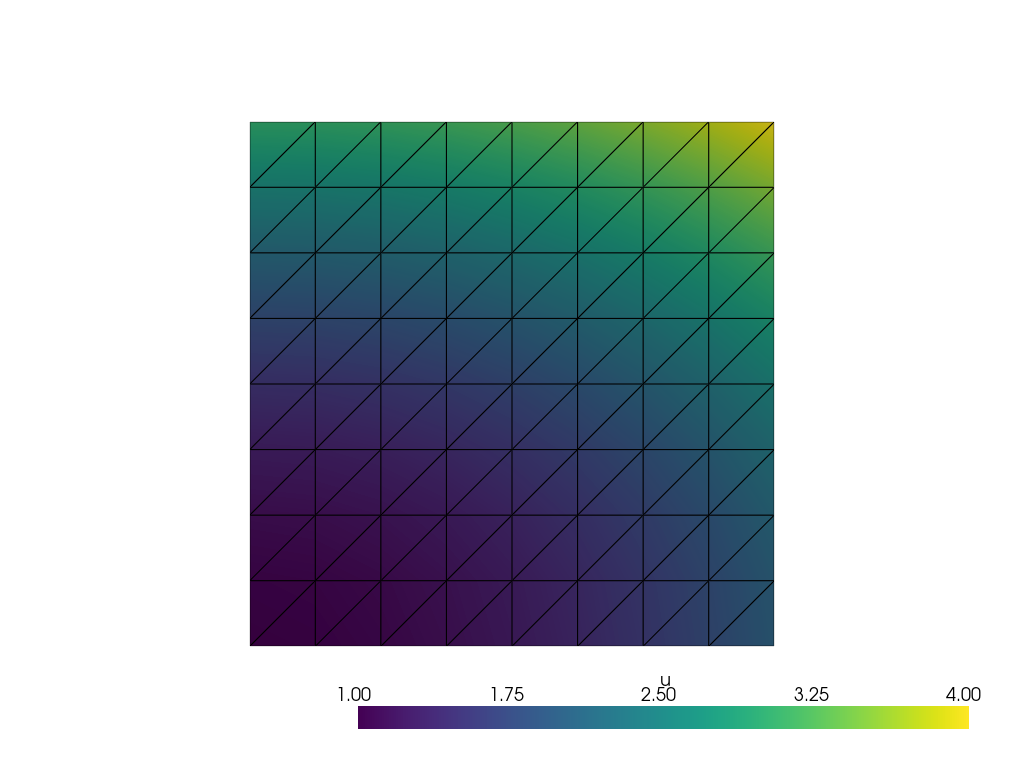

In [16]:
from mpi4py import MPI
from petsc4py.PETSc import ScalarType
import numpy as np
import ufl
from dolfinx import fem, mesh, io, plot
from dolfinx.fem.petsc import LinearProblem

# 1. Generate Mesh
domain = mesh.create_unit_square(MPI.COMM_WORLD, 8, 8, mesh.CellType.triangle)

# 2. Function space and Function
V = fem.functionspace(domain, ("Lagrange", 1))
uD = fem.Function(V)
uD.interpolate(lambda x: 1 + x[0]**2 + 2 * x[1]**2)

# 3. Boundary condition
tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)
boundary_facets = mesh.exterior_facet_indices(domain.topology)
boundary_dofs = fem.locate_dofs_topological(V, fdim, boundary_facets)
bc = fem.dirichletbc(uD, boundary_dofs)

# 4. Define weak form
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
f = fem.Constant(domain, ScalarType(-6))
a = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = f * v * ufl.dx

# 5. Solve
problem = LinearProblem(
    a, L, bcs=[bc],
    petsc_options_prefix="poisson_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
)
uh = problem.solve()

# 6. Check error
error_max = np.max(np.abs(uD.x.array - uh.x.array))
print(f"Max nodal error:   {error_max:.2e}")

V2 = fem.functionspace(domain, ("Lagrange", 2))
uex = fem.Function(V2)
uex.interpolate(lambda x: 1 + x[0]**2 + 2 * x[1]**2)
error_form = fem.form(ufl.inner(uh - uex, uh - uex) * ufl.dx)
error_local = fem.assemble_scalar(error_form)
error_L2 = np.sqrt(domain.comm.allreduce(error_local, op=MPI.SUM))
print(f"L2 error:          {error_L2:.2e}")

# ==============================================================================
# Step 2: Plot solution inline in Google Colab
# ==============================================================================
# Extract topology and geometry for PyVista
topology, cell_types, geometry = plot.vtk_mesh(V)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

# Attach solution values to grid nodes
grid.point_data["u"] = uh.x.array.real
grid.set_active_scalars("u")

# Create plot
plotter = pyvista.Plotter(notebook=True)
plotter.add_mesh(grid, show_edges=True, cmap="viridis")
plotter.view_xy()
plotter.show(jupyter_backend="static")